In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("MD_agric_exam-4313.csv")

In [3]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


In [5]:
unique_count = df["Crop_type"].nunique()

unique_count

8

### Maximum Annual Yield for Wheat in the dataset

In [10]:
wheat_df = round(df.loc[df['Crop_type'] == 'wheat', 'Annual_yield'].max(), 2)

wheat_df

8.99

### Finding total rainfall for crop types where average pollution level is above 0.2

In [13]:
rain_df = df.loc[df['Pollution_level'] > 0.2, 'Rainfall'].sum()

rain_df

478902.6

### A function to calculate the temperature range (Max_temperature_C - Min_temperature_C) for each farmer's field

In [25]:
def temp_range(field_id):
    temp_df = df.loc[df['Field_ID'] == field_id, 'Max_temperature_C'] - df.loc[df['Field_ID'] == field_id, 'Min_temperature_C']
    return temp_df

In [31]:
temp_range(1458)
temp_range(1895)
temp_range(5443)

892    33.4
dtype: float64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           1000 non-null   int64  
 1   Elevation          1000 non-null   float64
 2   Rainfall           1000 non-null   float64
 3   Min_temperature_C  1000 non-null   float64
 4   Max_temperature_C  1000 non-null   float64
 5   pH                 1000 non-null   float64
 6   Pollution_level    1000 non-null   float64
 7   Plot_size          1000 non-null   float64
 8   Annual_yield       1000 non-null   float64
 9   Crop_type          1000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 78.2+ KB


### What does this code achieve?

In [35]:
a = df['Crop_type'].unique()
b = float('inf')
c = ""

for crop in a:
    d = df[df['Crop_type'] == crop]['Min_temperature_C'].mean()
    
    if d < b:
        b = d
        c = crop
print(c)

rice


### Write code to calculate the total plot size for plots where the pH is less than 5.5

In [38]:
plot_df = df.loc[df['pH'] < 5.5, 'Plot_size'].sum()

plot_df

1731.8999999999999

In [36]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


### Filtering a DataFrame by two columns and counting the number of rows that meet the filtering criteria

In [48]:
new_df = df.loc[(df['Max_temperature_C'] > 30) & (df['Min_temperature_C'] < -5)]

len(new_df)

319

In [40]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


### Calculating the Standard Deviation of the 'Rainfall' for plots where the 'Plot_size' is larger than the median plot size of the dataset (round to 2 decimal places)

In [57]:
import numpy as np

plot_median = np.median(df['Plot_size'])
plot_mean = np.mean(df['Plot_size'])
plot_df = df.loc[df['Plot_size'] > plot_median]

std_plot = round(np.std(plot_df['Rainfall'], ddof=1), 2)

std_plot

470.09

### Concatenating strings from multiple columns

In [60]:
most_common = df['Max_temperature_C'].mode().iloc[0]
least_common = df['Crop_type'].value_counts().idxmin()

res = str(most_common)[:3] + str(least_common)[-3:]
print(res)

30.ice


In [58]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


### Write a Python code to create a violin plot visualising the distribution of 'Annual_yield' across different 'Elevation' ranges

<AxesSubplot:xlabel='Elevation_ranges', ylabel='Annual_yield'>

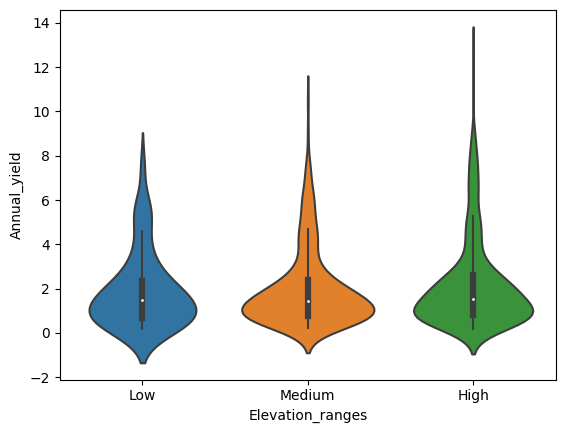

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Elevation_ranges'] = pd.cut(
    df['Elevation'],
    bins=[-float('inf'), 300, 600, float('inf')],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

sns.violinplot(x='Elevation_ranges', y='Annual_yield', data=df)

In [61]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


### A recursive function to sum the integer values for each unique crop type in the dataset

In [74]:
# df['len_by_name'] = df['Crop_type'].str.len()

# res = df.groupby('Crop_type')['len_by_name'].first()

# unique_crops = df['Crop_type'].drop_duplicates()
# lens = unique_crops.str.len()
# totals = lens.sum()

res = (
    df['Crop_type']
        .drop_duplicates()
        .str.len()
        .sum()
    )

res

42

In [68]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Elevation_ranges,len_by_name
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee,Medium,6
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato,High,6
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana,Medium,6
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat,Medium,5
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava,High,7


### Write a Python code to perform a t-test comparing the average 'Annual_yield' between 'coffee' and 'banana' crop types using scipy.stats. What is the p_value, rounded to three decimal places

In [76]:
from scipy.stats import ttest_ind

coffee = df.loc[df['Crop_type'] == 'coffee', 'Annual_yield']
banana = df.loc[df['Crop_type'] == 'banana', 'Annual_yield']

t_stat, p_value = ttest_ind(coffee, banana, equal_var=False)
round(p_value, 3)

0.598